# Artificial Neural Networks

## 1. Setup


In [17]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from model_wrappers import ThresholdedClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

FINAL_K = 30  # number of features selected — matches the shared value used in Preprocess_expanded.ipynb

In [18]:
try:
    X_train_raw = joblib.load("X_train_raw.pkl")
    X_test_raw = joblib.load("X_test_raw.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train_raw:", X_train_raw.shape, "y_train:", y_train.shape)
    print("X_test_raw :", X_test_raw.shape, "y_test :", y_test.shape)

Loaded successfully
X_train_raw: (3996, 42) y_train: (3996,)
X_test_raw : (1000, 42) y_test : (1000,)


## 1.2 Results Log 
**All exploratory/comparison entries use cross-validation on training data only** (`log_cv`) — the test set is not touched until the single \"Final Model Declaration\" section at the end (`log_test`), used exactly once.

In [19]:
results_log = []
candidate_models = {}

def log_cv(name, acc, model=None):
    """Log a cross-validated (train-only) accuracy estimate."""
    try:
        acc = float(acc)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "CV (train only)"})
    if model is not None:
        candidate_models[name] = model
    print(f"[Logged - CV] {name}: {acc:.4f}")
    return acc

def log_test(name, y_true, y_pred):
    """Log a genuine held-out test accuracy. Reserved for the FINAL declared model only."""
    try:
        acc = accuracy_score(y_true, y_pred)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "TEST (final, touched once)"})
    print(f"[Logged - TEST] {name}: {acc:.4f}")
    return acc

## 2. Baseline Model 
Arbitrary ANN hyperparameters, wrapped in a `Pipeline` with feature selection and scaling.

In [20]:
baseline_pipeline = Pipeline([
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42
    ))
])

try:
    cv_scores = cross_val_score(baseline_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during baseline cross-validation: {e}")
else:
    print("Baseline 10-fold CV Accuracy:", cv_scores.mean())
    log_cv("Baseline (64,32 hidden layers)", cv_scores.mean(), model=baseline_pipeline)

Baseline 10-fold CV Accuracy: 0.7865401002506265
[Logged - CV] Baseline (64,32 hidden layers): 0.7865


## 3. Hyperparameter Tuning 
Grid Search now tunes the full `Pipeline` together, so `SelectKBest` and `StandardScaler` are refit independently inside every one of the 10 folds.

In [21]:
pipeline = Pipeline([
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(max_iter=3000, random_state=42))
])

param_grid = {
    "clf__hidden_layer_sizes": [(64, 32)],
    "clf__activation": ["relu"],
    "clf__learning_rate_init": [0.001, 0.002, 0.005],
    "clf__alpha": [0.0001, 0.001],
    "clf__solver": ["adam"],
    "clf__early_stopping": [True, False]
}

try:
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=10,
        scoring="accuracy",
        n_jobs=-1
    )
    grid_search.fit(X_train_raw, y_train)
except (ValueError, RuntimeError) as e:
    print(f"Error during Grid Search: {e}")
else:
    best_pipeline = grid_search.best_estimator_
    print("========== Best Hyperparameters ==========")
    print(grid_search.best_params_)
    print("\nBest Cross Validation Accuracy:")
    print(f"{grid_search.best_score_:.4f}")
    log_cv("Grid Search Tuned", grid_search.best_score_, model=best_pipeline)

========== Best Hyperparameters ==========
{'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__early_stopping': True, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.005, 'clf__solver': 'adam'}

Best Cross Validation Accuracy:
0.7948
[Logged - CV] Grid Search Tuned: 0.7948


## 4. Training-Set Sanity Check 
The real generalization gap is confirmed once, honestly, in the Final Model Declaration section.

In [22]:
try:
    train_accuracy = best_pipeline.score(X_train_raw, y_train)
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error evaluating training accuracy: {e}")
else:
    print("Training Accuracy (best pipeline):", train_accuracy)

Training Accuracy (best pipeline): 0.8676176176176176


## 5. Model Stability — Cross-Validation

[0.815      0.7975     0.7725     0.8025     0.8        0.79
 0.8245614  0.80200501 0.77192982 0.77192982]
Average CV Accuracy: 0.7947926065162907


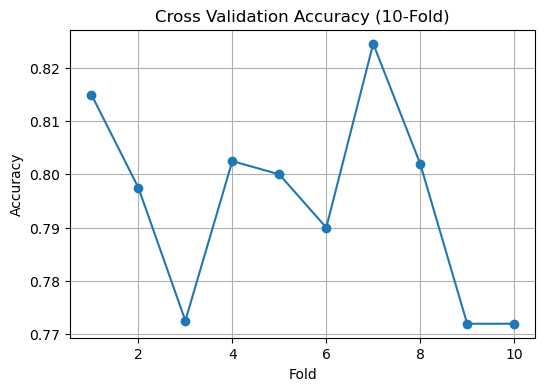

In [23]:
try:
    cv_scores = cross_val_score(best_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during cross-validation: {e}")
else:
    print(cv_scores)
    print("Average CV Accuracy:", cv_scores.mean())

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 11), cv_scores, marker="o")
    plt.title("Cross Validation Accuracy (10-Fold)")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

## 6. Decision Threshold Optimization (Youden's J Statistic) 
The optimal threshold is found using **out-of-fold predicted probabilities on the training set only** — the test set plays no role in choosing it.

In [24]:
try:
    y_train_probs = cross_val_predict(best_pipeline, X_train_raw, y_train, cv=10, method="predict_proba")[:, 1]
    fpr, tpr, thresholds = roc_curve(y_train, y_train_probs)
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    y_train_pred_optimal = (y_train_probs >= best_threshold).astype(int)
except (ValueError, AttributeError, RuntimeError) as e:
    print(f"Error during threshold optimization: {e}")
else:
    print(f"Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): {best_threshold:.4f}")
    print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
    cv_thresholded_acc = accuracy_score(y_train, y_train_pred_optimal)
    print("Out-of-fold accuracy at this threshold (train, CV-based):", cv_thresholded_acc)
    log_cv("Grid Search + Youden's J", cv_thresholded_acc, model=(best_pipeline, best_threshold))

Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): 0.5621
Youden's J at this threshold: 0.5890
Out-of-fold accuracy at this threshold (train, CV-based): 0.7962962962962963
[Logged - CV] Grid Search + Youden's J: 0.7963


## 6.2 L2 Regularization (Weight Decay) — the formula behind `alpha` 
ANN's model-specific \"extra formula\": `alpha` is the coefficient on an **L2 regularization term** added directly to the network's loss function: \n\n$$Loss = Original\\_Loss + \\alpha \\sum w^2$$ \n\nThis penalizes large weights, discouraging the network from relying too heavily on any single connection. The cell below sweeps `alpha` directly (10-fold CV, training data only) using the other best hyperparameters found by Grid Search.

[Logged - CV] L2 Regularization (alpha=1e-05): 0.7880
[Logged - CV] L2 Regularization (alpha=0.0001): 0.7948
[Logged - CV] L2 Regularization (alpha=0.001): 0.7903
[Logged - CV] L2 Regularization (alpha=0.01): 0.7920
[Logged - CV] L2 Regularization (alpha=0.1): 0.7935
[Logged - CV] L2 Regularization (alpha=1.0): 0.7948


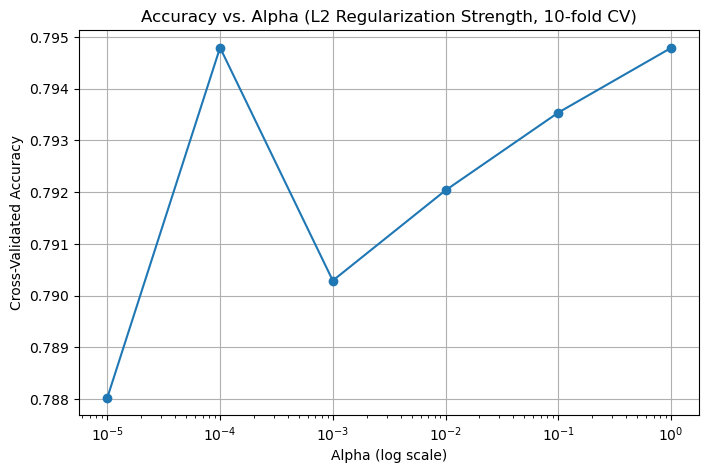

In [25]:
best_params = grid_search.best_params_

alpha_range = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]
alpha_scores = []

try:
    for a in alpha_range:
        temp_pipeline = Pipeline([
            ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=best_params["clf__hidden_layer_sizes"],
                activation=best_params["clf__activation"],
                learning_rate_init=best_params["clf__learning_rate_init"],
                solver=best_params["clf__solver"],
                early_stopping=best_params["clf__early_stopping"],
                alpha=a,
                max_iter=3000,
                random_state=42
            ))
        ])
        cv_result = cross_val_score(temp_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
        alpha_scores.append(cv_result.mean())
        log_cv(f"L2 Regularization (alpha={a})", cv_result.mean(), model=temp_pipeline)
except (ValueError, RuntimeError) as e:
    print(f"Error during alpha sweep: {e}")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(alpha_range, alpha_scores, marker="o")
    plt.xscale("log")
    plt.title("Accuracy vs. Alpha (L2 Regularization Strength, 10-fold CV)")
    plt.xlabel("Alpha (log scale)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.grid(True)
    plt.show()

## 6.3 Probability Calibration

ANNs (and many classifiers) don't always produce well-calibrated probabilities — the model might 
be systematically overconfident or underconfident, even when its *ranking* of patients from 
low-to-high risk is accurate. `CalibratedClassifierCV` fixes this by learning a correction mapping 
from raw predicted probabilities to better-calibrated ones, using an internal cross-validation split 
so the calibration itself isn't fit on the same data it's evaluated on. This matters directly for 
this project: both Youden's J thresholding (Section 6) and the deployed app's prediction confidence 
depend on `predict_proba()` being meaningful, not just correctly ranked.

In [ ]:
calibrated_pipeline = CalibratedClassifierCV(
    estimator=best_pipeline,
    method="sigmoid",  # good default for smaller datasets; try "isotonic" if you have a lot of data
    cv=5                # internal CV used to fit the calibration mapping itself
)

try:
    calibrated_cv_scores = cross_val_score(calibrated_pipeline, X_train_raw, y_train, cv=10, scoring="accuracy")
except (ValueError, RuntimeError) as e:
    print(f"Error during calibration cross-validation: {e}")
else:
    print("Calibrated Model 10-fold CV Accuracy:", calibrated_cv_scores.mean())
    log_cv("Probability Calibration (sigmoid)", calibrated_cv_scores.mean(), model=calibrated_pipeline)

## 7. Final Model Declaration & Held-Out Test Evaluation 
Every candidate above was compared using cross-validation on training data only. This section picks the candidate with the **highest CV accuracy** and evaluates it on `X_test_raw` / `y_test` — the only place in this notebook the test set is used.

In [ ]:
cv_log = pd.DataFrame([r for r in results_log if r["Type"] == "CV (train only)"])
print(cv_log)

best_row = cv_log.loc[cv_log["Accuracy"].idxmax()]
best_stage_name = best_row["Stage"]
print(f"\n>>> Final chosen model: '{best_stage_name}' (CV accuracy = {best_row['Accuracy']:.4f})")

In [ ]:
chosen = candidate_models[best_stage_name]

if isinstance(chosen, tuple):
    inner_pipeline, final_threshold = chosen
    inner_pipeline.fit(X_train_raw, y_train)
    final_model_to_save = ThresholdedClassifier(inner_pipeline, threshold=final_threshold)
    final_model_to_save.classes_ = inner_pipeline.classes_
    final_pred = final_model_to_save.predict(X_test_raw)
    print(f"Final model is '{best_stage_name}' with a custom threshold of {final_threshold:.4f}")
else:
    final_pipeline = chosen
    final_pipeline.fit(X_train_raw, y_train)
    final_pred = final_pipeline.predict(X_test_raw)
    final_model_to_save = final_pipeline

test_accuracy = log_test(f"FINAL: {best_stage_name}", y_test, final_pred)
print(classification_report(y_test, final_pred))

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, cmap="Blues")
plt.title(f"Final ANN Model Confusion Matrix ({best_stage_name})", fontsize=13, loc='left')
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.xlabel("Predicted label", fontsize=10)
plt.ylabel("True label", fontsize=10)
plt.show()

## Permutation Importance

In [ ]:
# Run permutation importance on the test set using the fitted pipeline
pi_result = permutation_importance(
    final_model_to_save, 
    X_test_raw, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='accuracy'
)

# Sort and display feature importances
sorted_importances_idx = pi_result.importances_mean.argsort()[::-1]
for i in sorted_importances_idx:
    print(f"{X_test_raw.columns[i]:<30}: {pi_result.importances_mean[i]:.4f} +/- {pi_result.importances_std[i]:.4f}")

## 7.2 Training Diagnostics — Loss Curve & Convergence 
Unlike KNN and SVM, `MLPClassifier` genuinely supports this: it's trained via iterative gradient-based optimization, and scikit-learn records the loss at every iteration. Shown here for the final declared model, refit on the full training set above.

In [ ]:
try:
    final_clf = final_pipeline.named_steps["clf"]
    plt.figure(figsize=(6, 4))
    plt.plot(final_clf.loss_curve_)
    plt.title("ANN Training Loss Curve (Final Model)")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    print("Number of Iterations:", final_clf.n_iter_)
    print("Final Loss:", final_clf.loss_)
except AttributeError as e:
    print(f"Loss curve not available for this solver/model: {e}")

**Important note for `app.py`:** the saved model below is a full `Pipeline` (feature selection + scaling + classifier combined), not a bare classifier. Any manual scaling/feature-selection currently done in `app.py` should be **removed** — pass the full raw feature row directly to `final_model.predict()` and let the pipeline handle the rest internally.

## 8. Full Accuracy Progression Log

In [ ]:
log_df = pd.DataFrame(results_log)
log_df

In [ ]:
# save the trained model
try:
    joblib.dump(final_model_to_save, 'ann_model.pkl')
except (OSError, PermissionError) as e:
    print(f"Error saving model: {e}")
else:
    print(f"Model saved successfully! ('{best_stage_name}', test accuracy = {test_accuracy:.4f})")